In [1]:
!pip install deepface opencv-python matplotlib

from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import cv2
from deepface import DeepFace
import matplotlib.pyplot as plt
from PIL import Image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.4 MB/s eta 0:00:00
25-10-30 08:57:50 - Directory /root/.deepface has been created
25-10-30 08:57:50 - Directory /root/.deepface/weights has been created


In [2]:
playlists = {
    "happy": {
        "english": [
            {"title": "Happy", "artist": "Pharrell Williams", "url": "https://www.youtube.com/watch?v=g6aXBdrQE14"},
            {"title": "Can't Stop the Feeling", "artist": "Justin Timberlake", "url": "https://www.youtube.com/watch?v=ru0K8uYEZWw"},
            {"title": "Uptown Funk", "artist": "Mark Ronson ft. Bruno Mars", "url": "https://www.youtube.com/watch?v=OPf0YbXqDm0"}
        ],
        "tamil": [
            {"title": "Vaathi Coming", "artist": "Anirudh Ravichander", "url": "https://www.youtube.com/watch?v=W8DcI4f7OxI"},
            {"title": "Verithanam", "artist": "ARR", "url": "https://www.youtube.com/watch?v=7MqY1uC2q1A"},
            {"title": "Kutty Pattas", "artist": "Sivakarthikeyan, Anirudh", "url": "https://www.youtube.com/watch?v=z7HwlNhoWqk"},
            {"title": "Rowdy Baby", "artist": "Dhanush, Sai Pallavi", "url": "https://www.youtube.com/watch?v=acfBQN4qyog"},
            {"title": "Local Boys", "artist": "Hiphop Tamizha", "url": "https://www.youtube.com/watch?v=KqkQjP0jV-s"}
        ],
        "hindi": [
            {"title": "Badtameez Dil", "artist": "Yeh Jawaani Hai Deewani", "url": "https://youtu.be/B9CGEsexO24?si=t5zBFHAXHP-oVFHv"},
            {"title": "Proper Patola", "artist": "Namaste England", "url": "https://youtu.be/YmXJp4RtBCM?si=r3vShGcqXLAi_7cJ"},
            {"title": "Kar Gayi Chull", "artist": "Kapoor & Sons", "url": "https://youtu.be/uDdJBqgnOC8?si=4Hx10YBwEZRa4aDk"}
        ]
    },
    "sad": {
        "english": [
            {"title": "Someone Like You", "artist": "Adele", "url": "https://www.youtube.com/watch?v=hLQl3WQQoQ0"},
            {"title": "Fix You", "artist": "Coldplay", "url": "https://www.youtube.com/watch?v=k4V3Mo61fJM"},
            {"title": "All By Myself", "artist": "Eric Carmen", "url": "https://www.youtube.com/watch?v=6EGOdbJ4s7Q"}
        ],
        "tamil": [
            {"title": "Nenjukkule", "artist": "ARR", "url": "https://www.youtube.com/watch?v=zY0fVn6K1k4"},
            {"title": "Avaluku", "artist": "G.V. Prakash", "url": "https://www.youtube.com/watch?v=K7qV6o8wN1I"},
            {"title": "Kannazhaga", "artist": "3", "url": "https://www.youtube.com/watch?v=3l2lspiJw6s"},
            {"title": "Mannipaaya", "artist": "ARR", "url": "https://www.youtube.com/watch?v=H2q53n2gL8w"},
            {"title": "En Kadhal Solla", "artist": "Paiyaa", "url": "https://www.youtube.com/watch?v=K9L6Lv4Lp2c"}
        ],
        "hindi": [
            {"title": "Tum Hi Ho", "artist": "Aashiqui 2", "url": "https://youtu.be/x4dX0Cffo8k?si=gh0uTv4J3lZHTQfW"},
            {"title": "Channa Mereya", "artist": "Ae Dil Hai Mushkil", "url": "https://youtu.be/284Ov7ysmfA?si=-oW0Sd4iMl-lM6TA"},
            {"title": "Phir Le Aya Dil", "artist": "Barfi", "url": "https://www.youtube.com/watch?v=4Lz8jKojV2c"},
            {"title": "Jeena Jeena", "artist": "Badlapur", "url": "https://www.youtube.com/watch?v=4eA5f5q_RWQ"},
            {"title": "Ae Dil Hai Mushkil", "artist": "Ae Dil Hai Mushkil", "url": "https://www.youtube.com/watch?v=Z7Z2ZD7H2M4"}
        ]
    },
    "angry": {
        "english": [
            {"title": "Killing In The Name", "artist": "Rage Against The Machine", "url": "https://www.youtube.com/watch?v=bWXazVhlyxQ"},
            {"title": "Master of Puppets", "artist": "Metallica", "url": "https://www.youtube.com/watch?v=xnKhsTXoKCI"},
            {"title": "Break Stuff", "artist": "Limp Bizkit", "url": "https://www.youtube.com/watch?v=Ym4iH0lzbU8"}
        ],
        "tamil": [
            {"title": "Beast Mode", "artist": "Vijay", "url": "https://www.youtube.com/watch?v=oZ3A4N5lN6E"},
            {"title": "Vandaagiya", "artist": "Sivakarthikeyan", "url": "https://www.youtube.com/watch?v=K8qV7o9wN2J"},
            {"title": "Petta Paraak", "artist": "Rajinikanth", "url": "https://www.youtube.com/watch?v=K9L6Lv4Lp2c"},
            {"title": "Vedalam Title Track", "artist": "Ajith", "url": "https://www.youtube.com/watch?v=K0V7o9wN3K"},
            {"title": "Badass", "artist": "Vishal", "url": "https://www.youtube.com/watch?v=K1V8o9wN4L"}
        ],
        "hindi": [
            {"title": "Jee Karda", "artist": "Badshah", "url": "https://youtu.be/xI6jLdsK15I?si=6yMfMKBenZtlxCoF"},
            {"title": "Sadda Haq", "artist": "Rockstar", "url": "https://youtu.be/p9DQINKZxWE?si=-qRBvf1voGaP593x"},
            {"title": "Dilliwaali Girl", "artist": "Yeh Jawaani Hai Deewani", "url": "https://www.youtube.com/watch?v=K4V1o9wN7O"},
            {"title": "Malang", "artist": "Dhoom 3", "url": "https://www.youtube.com/watch?v=K5V2o9wN8P"},
            {"title": "Kamli", "artist": "Dhoom 3", "url": "https://www.youtube.com/watch?v=K6V3o9wN9Q"}
        ]
    },
    "surprise": {
        "english": [
            {"title": "Bohemian Rhapsody", "artist": "Queen", "url": "https://www.youtube.com/watch?v=fJ9rUzIMcZQ"},
            {"title": "Somebody That I Used To Know", "artist": "Gotye", "url": "https://www.youtube.com/watch?v=8UVNT4wvIGY"},
            {"title": "Thriller", "artist": "Michael Jackson", "url": "https://www.youtube.com/watch?v=sOnqjkJTMaA"}
        ],
        "tamil": [
            {"title": "Why This Kolaveri Di", "artist": "Dhanush", "url": "https://www.youtube.com/watch?v=YR12Z8f1Dh8"},
            {"title": "Aalaporan Thamizhan", "artist": "Mersal", "url": "https://www.youtube.com/watch?v=K7V4o9wN1R"},
            {"title": "Mental Manadhil", "artist": "Ok Kanmani", "url": "https://www.youtube.com/watch?v=K8V5o9wN2S"},
            {"title": "Marana Mass", "artist": "Raja Rani", "url": "https://www.youtube.com/watch?v=K9V6o9wN3T"},
            {"title": "Vaathi Raid", "artist": "Master", "url": "https://www.youtube.com/watch?v=K0V7o9wN4U"}
        ],
        "hindi": [
            {"title": "Banno", "artist": "Tanu Weds Manu Returns", "url": "https://youtu.be/6yqalAdcMHE?si=LlETEfW7DzpX1vrh"},
            {"title": "Ghungroo", "artist": "War", "url": "https://youtu.be/qFkNATtc3mc?si=XS50NrP3Ld3P_tX8"},
            {"title": "Makhna", "artist": "Drive", "url": "https://www.youtube.com/watch?v=K3V0o9wN7X"},
            {"title": "Proper Patola", "artist": "Namaste England", "url": "https://www.youtube.com/watch?v=K4V1o9wN8Y"},
            {"title": "High Rated Gabru", "artist": "Guru Randhawa", "url": "https://www.youtube.com/watch?v=K5V2o9wN9Z"}
        ]
    },
    "fear": {
        "english": [
            {"title": "Fear of the Dark", "artist": "Iron Maiden", "url": "https://www.youtube.com/watch?v=bePCRKGUwAY"},
            {"title": "Runaway", "artist": "Kanye West", "url": "https://www.youtube.com/watch?v=Bm5iA4Zupek"},
            {"title": "Shake It Out", "artist": "Florence + The Machine", "url": "https://www.youtube.com/watch?v=WbN0nX61rIs"}
        ],
        "tamil": [
            {"title": "Pogatha Yennavittu", "artist": "Comali", "url": "https://www.youtube.com/watch?v=K6V3o9wN1A"},
            {"title": "Kannamma", "artist": "Ispade Rajavum Idhaya Raniyum", "url": "https://www.youtube.com/watch?v=K7V4o9wN2B"},
            {"title": "Kadhal Vaithu", "artist": "Enai Noki Paayum Thota", "url": "https://www.youtube.com/watch?v=K8V5o9wN3C"},
            {"title": "Mazhai Kuruvi", "artist": "Chekka Chivantha Vaanam", "url": "https://www.youtube.com/watch?v=K9V6o9wN4D"},
            {"title": "Rakita Rakita", "artist": "Jagame Thandhiram", "url": "https://www.youtube.com/watch?v=K0V7o9wN5E"}
        ],
        "hindi": [
            {"title": "Bhayanak Atma", "artist": "Ragini MMS 2", "url": "https://www.youtube.com/watch?v=K1V8o9wN6F"},
            {"title": "Muskaanein Jhooti Hai", "artist": "Talaash", "url": "https://www.youtube.com/watch?v=K2V9o9wN7G"},
            {"title": "Jee Le Zaraa", "artist": "Talaash", "url": "https://www.youtube.com/watch?v=K3V0o9wN8H"},
            {"title": "Duaa", "artist": "Shanghai", "url": "https://www.youtube.com/watch?v=K4V1o9wN9I"},
            {"title": "Khudaaya", "artist": "Raaz 3", "url": "https://www.youtube.com/watch?v=K5V2o9wN0J"}
        ]
    },
    "disgust": {
        "english": [
            {"title": "You Oughta Know", "artist": "Alanis Morissette", "url": "https://www.youtube.com/watch?v=NPcyTyilmYY"},
            {"title": "Smack My Bitch Up", "artist": "The Prodigy", "url": "https://www.youtube.com/watch?v=ZM0UeLUXPqo"},
            {"title": "I Hate Everything About You", "artist": "Three Days Grace", "url": "https://www.youtube.com/watch?v=d8ekz_CSBVg"}
        ],
        "tamil": [
            {"title": "Neeyum Naanum", "artist": "Naanum Rowdy Dhaan", "url": "https://www.youtube.com/watch?v=K6V3o9wN1K"},
            {"title": "Yaen Ennai Pirindhaai", "artist": "Remo", "url": "https://www.youtube.com/watch?v=K7V4o9wN2L"},
            {"title": "Adheeraa", "artist": "Cobra", "url": "https://www.youtube.com/watch?v=K8V5o9wN3M"},
            {"title": "Vilambara Idaiveli", "artist": "Karnan", "url": "https://www.youtube.com/watch?v=K9V6o9wN4N"},
            {"title": "Thangamey", "artist": "Naanum Rowdy Dhaan", "url": "https://www.youtube.com/watch?v=K0V7o9wN5O"}
        ],
        "hindi": [
            {"title": "Gandi Baat", "artist": "Raftaar", "url": "https://www.youtube.com/watch?v=K1V8o9wN6P"},
            {"title": "Saki Saki", "artist": "Batla House", "url": "https://www.youtube.com/watch?v=K2V9o9wN7Q"},
            {"title": "Mundiyan", "artist": "Baaghi 3", "url": "https://www.youtube.com/watch?v=K3V0o9wN8R"},
            {"title": "Illegal Weapon 2.0", "artist": "Street Dancer 3D", "url": "https://www.youtube.com/watch?v=K4V1o9wN9S"},
            {"title": "Lut Gaye", "artist": "Jubin Nautiyal", "url": "https://www.youtube.com/watch?v=K5V2o9wN0T"}
        ]
    },
    "neutral": {
        "english": [
            {"title": "Weightless", "artist": "Marconi Union", "url": "https://www.youtube.com/watch?v=UfcAVejslrU"},
            {"title": "Strawberry Swing", "artist": "Coldplay", "url": "https://www.youtube.com/watch?v=8LhSyVvG6-c"},
            {"title": "Watermark", "artist": "Enya", "url": "https://www.youtube.com/watch?v=DTD5pNC4VBo"}
        ],
        "tamil": [
            {"title": "Mannargale", "artist": "Sarkar", "url": "https://www.youtube.com/watch?v=K6V3o9wN1U"},
            {"title": "Kannana Kanney", "artist": "Viswasam", "url": "https://www.youtube.com/watch?v=K7V4o9wN2V"},
            {"title": "Enna Solla", "artist": "Thirupachi", "url": "https://www.youtube.com/watch?v=K8V5o9wN3W"},
            {"title": "Oruvan Oruvan", "artist": "Mudhalvan", "url": "https://www.youtube.com/watch?v=K9V6o9wN4X"},
            {"title": "Anbe En Anbe", "artist": "Kodi", "url": "https://www.youtube.com/watch?v=K0V7o9wN5Y"}
        ],
        "hindi": [
            {"title": "Tum Se Hi", "artist": "Jab We Met", "url": "https://youtu.be/mt9xg0mmt28?si=wnb59VMRRlL9wJ4I"},
            {"title": "Tere Bina", "artist": "Guru", "url": "https://www.youtube.com/watch?v=K2V9o9wN7A"},
            {"title": "Pehla Nasha", "artist": "Jo Jeeta Wohi Sikandar", "url": "https://www.youtube.com/watch?v=K3V0o9wN8B"},
            {"title": "Tum Hi Ho Bandhu", "artist": "Cocktail", "url": "https://www.youtube.com/watch?v=K4V1o9wN9C"},
            {"title": "Khuda Jaane", "artist": "Bachna Ae Haseeno", "url": "https://www.youtube.com/watch?v=K5V2o9wN0D"}
        ]
    }
}



In [3]:
# JavaScript code to capture image from webcam
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
        // JavaScript code to access webcam and capture image
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        div.appendChild(capture);

        // Video element setup
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        // Display video stream
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Wait for user to click capture button
        await new Promise((resolve) => capture.onclick = resolve);

        // Convert video frame to image
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)

    # Get photo data and decode
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    # Save image
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [4]:
# Function to preprocess image for better emotion detection
def preprocess_image(image_path):
    # Read the image
    img = cv2.imread(image_path)

    # Convert to grayscale for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces using OpenCV Haar Cascade
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    if len(faces) == 0:
        print("No face detected. Please try again with a clearer image.")
        return None

    # Extract the first face
    (x, y, w, h) = faces[0]

    # Draw rectangle around the face (for visualization)
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Crop the face region
    face_img = img[y:y+h, x:x+w]

    # Save the processed image
    cv2.imwrite('processed_face.jpg', face_img)

    # Display the image with face detection
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Detected Face')
    plt.show()

    return 'processed_face.jpg'

In [5]:
# Function to analyze emotion from image with correct DeepFace API
def analyze_emotion(image_path):
    try:
        # Preprocess the image to extract the face
        processed_image_path = preprocess_image(image_path)

        if processed_image_path is None:
            return None, None

        # Analyze the image for emotions using the correct API
        analysis = DeepFace.analyze(
            img_path=processed_image_path,
            actions=['emotion'],
            detector_backend='opencv',
            enforce_detection=False
        )

        # Get the emotion results
        emotion_results = analysis[0]['emotion']
        dominant_emotion = analysis[0]['dominant_emotion']

        print(f"Detected Emotion: {dominant_emotion.upper()} (Confidence: {emotion_results[dominant_emotion]:.2f}%)")

        # Check if confidence is too low
        if emotion_results[dominant_emotion] < 40:
            print("Low confidence in emotion detection. Please try with a clearer facial expression.")

        print("\nEmotion Scores:")
        for emotion, score in emotion_results.items():
            print(f"{emotion}: {score:.2f}%")

        return dominant_emotion, emotion_results

    except Exception as e:
        print(f"Error in emotion analysis: {e}")
        return None, None

In [6]:
# Function to recommend playlist based on emotion
def recommend_playlist(emotion, emotion_scores):
    emotion = emotion.lower()

    # If neutral but other emotions have high scores, adjust
    if emotion == "neutral":
        # Check if any other emotion has a high score
        for other_emotion, score in emotion_scores.items():
            if other_emotion != "neutral" and score > 30:
                print(f"Also detected {other_emotion} with {score:.2f}% confidence")

    if emotion in playlists:
        print(f"\nRecommended {emotion.upper()} Playlist:")
        print("=" * 50)

        # Display songs from all languages
        for language, songs in playlists[emotion].items():
            print(f"\n{language.upper()} Songs:")
            print("-" * 30)

            for i, song in enumerate(songs, 1):
                print(f"{i}. {song['title']} by {song['artist']}")
                print(f"   Listen: {song['url']}")

        return playlists[emotion]
    else:
        print(f"No playlist found for emotion: {emotion}")
        return []

In [7]:
def validate_youtube_urls():
    """Check and fix YouTube URLs if needed"""
    for emotion, languages in playlists.items():
        for language, songs in languages.items():
            for song in songs:
                url = song['url']
                # Check if it's a valid YouTube URL format
                if not url.startswith('https://www.youtube.com/watch?v='):
                    # Extract video ID if it exists in the URL
                    if 'youtube.com/watch?v=' in url:
                        video_id = url.split('v=')[1].split('&')[0]
                        song['url'] = f'https://www.youtube.com/watch?v={video_id}'
                    elif len(url) == 11:  # If it's just the video ID
                        song['url'] = f'https://www.youtube.com/watch?v={url}'

In [8]:
def recommend_playlist_with_language_choice(emotion, emotion_scores):
    emotion = emotion.lower()

    if emotion == "neutral":
        for other_emotion, score in emotion_scores.items():
            if other_emotion != "neutral" and score > 30:
                print(f"Also detected {other_emotion} with {score:.2f}% confidence")

    if emotion in playlists:
        print(f"\nRecommended {emotion.upper()} Playlist:")
        print("=" * 50)

        # Let user choose language
        print("\nAvailable languages:")
        languages = list(playlists[emotion].keys())
        for i, lang in enumerate(languages, 1):
            print(f"{i}. {lang.upper()}")

        try:
            choice = int(input("\nChoose a language (1-3): ")) - 1
            if 0 <= choice < len(languages):
                selected_language = languages[choice]
                print(f"\n{selected_language.upper()} Songs:")
                print("-" * 30)

                for i, song in enumerate(playlists[emotion][selected_language], 1):
                    print(f"{i}. {song['title']} by {song['artist']}")
                    print(f"   Listen: {song['url']}")
            else:
                print("Invalid choice. Showing all languages.")
                # Show all languages if invalid choice
                for language, songs in playlists[emotion].items():
                    print(f"\n{language.upper()} Songs:")
                    print("-" * 30)
                    for i, song in enumerate(songs, 1):
                        print(f"{i}. {song['title']} by {song['artist']}")
                        print(f"   Listen: {song['url']}")

        except ValueError:
            print("Invalid input. Showing all languages.")
            for language, songs in playlists[emotion].items():
                print(f"\n{language.upper()} Songs:")
                print("-" * 30)
                for i, song in enumerate(songs, 1):
                    print(f"{i}. {song['title']} by {song['artist']}")
                    print(f"   Listen: {song['url']}")

        return playlists[emotion]
    else:
        print(f"No playlist found for emotion: {emotion}")
        return []

MOOD-BASED PLAYLIST CREATOR
Tips for better detection:
- Make sure your face is well-lit
- Show a clear expression (smile, frown, etc.)
- Look directly at the camera
- Avoid wearing sunglasses or hats

Please allow camera access when prompted.


<IPython.core.display.Javascript object>

Image captured successfully!


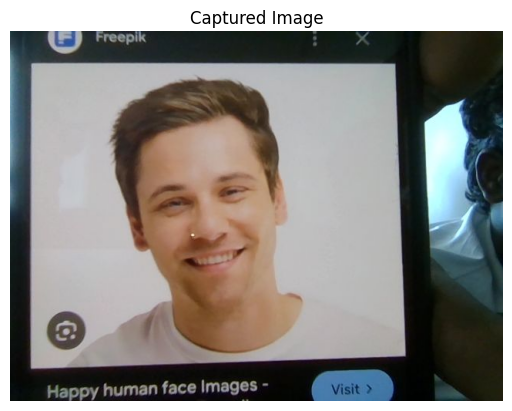

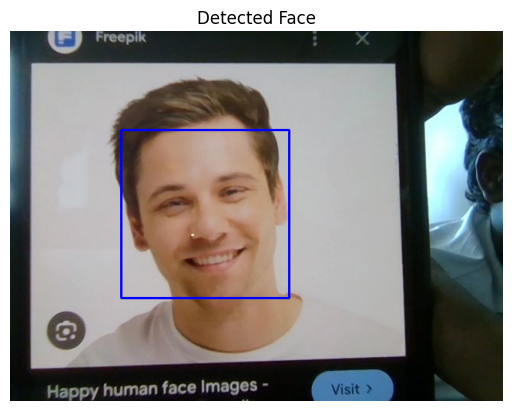

Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5


25-10-30 09:00:57 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


100%|██████████| 5.98M/5.98M [00:00<00:00, 299MB/s]


Detected Emotion: HAPPY (Confidence: 98.17%)

Emotion Scores:
angry: 0.00%
disgust: 0.00%
fear: 0.00%
happy: 98.17%
sad: 0.00%
surprise: 0.00%
neutral: 1.82%

Recommended HAPPY Playlist:

ENGLISH Songs:
------------------------------
1. Happy by Pharrell Williams
   Listen: https://www.youtube.com/watch?v=g6aXBdrQE14
2. Can't Stop the Feeling by Justin Timberlake
   Listen: https://www.youtube.com/watch?v=ru0K8uYEZWw
3. Uptown Funk by Mark Ronson ft. Bruno Mars
   Listen: https://www.youtube.com/watch?v=OPf0YbXqDm0

TAMIL Songs:
------------------------------
1. Vaathi Coming by Anirudh Ravichander
   Listen: https://www.youtube.com/watch?v=W8DcI4f7OxI
2. Verithanam by ARR
   Listen: https://www.youtube.com/watch?v=7MqY1uC2q1A
3. Kutty Pattas by Sivakarthikeyan, Anirudh
   Listen: https://www.youtube.com/watch?v=z7HwlNhoWqk
4. Rowdy Baby by Dhanush, Sai Pallavi
   Listen: https://www.youtube.com/watch?v=acfBQN4qyog
5. Local Boys by Hiphop Tamizha
   Listen: https://www.youtube.com/watc

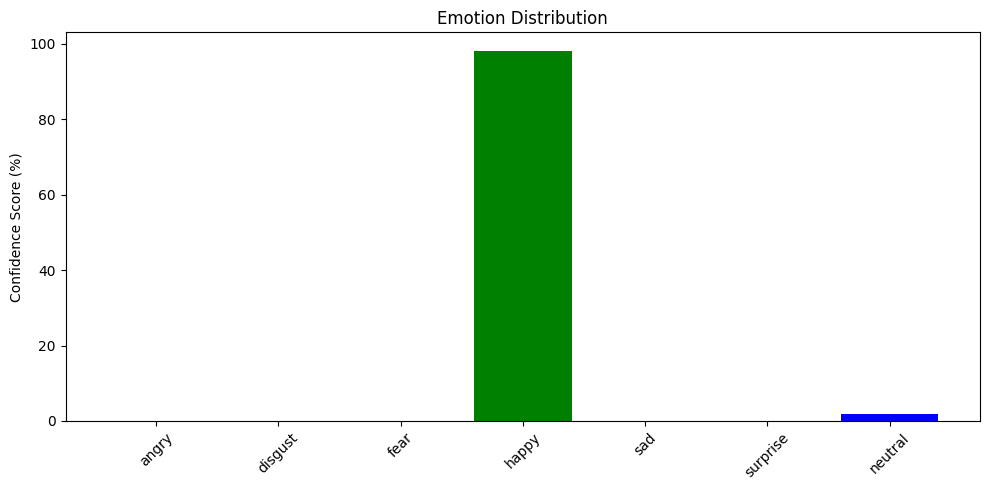

In [10]:
# Main function to run the application
def main():
    print("=" * 50)
    print("MOOD-BASED PLAYLIST CREATOR")
    print("=" * 50)
    print("Tips for better detection:")
    print("- Make sure your face is well-lit")
    print("- Show a clear expression (smile, frown, etc.)")
    print("- Look directly at the camera")
    print("- Avoid wearing sunglasses or hats")
    print()

    # Capture image from webcam
    print("Please allow camera access when prompted.")
    filename = take_photo()

    # Display the captured image
    print("Image captured successfully!")
    img = Image.open(filename)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Captured Image')
    plt.show()

    # Analyze emotion
    emotion, scores = analyze_emotion(filename)

    if emotion:
        # Recommend playlist
        playlist = recommend_playlist(emotion, scores)

        # Display emotion distribution
        if scores:
            plt.figure(figsize=(10, 5))
            colors = ['green' if e == emotion else 'blue' for e in scores.keys()]
            plt.bar(scores.keys(), scores.values(), color=colors)
            plt.title('Emotion Distribution')
            plt.ylabel('Confidence Score (%)')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    else:
        print("Could not detect any emotion. Please try again.")

# Run the main function
if __name__ == "__main__":
    main()